In [1]:
# Download KING

%cd ~
!wget https://www.kingrelatedness.com/Linux-king.tar.gz
!tar -xzf Linux-king.tar.gz
!chmod +x king
%cd ~/cse284-relative-finding

/home/r3james
--2026-03-14 03:41:56--  https://www.kingrelatedness.com/Linux-king.tar.gz
Resolving www.kingrelatedness.com (www.kingrelatedness.com)... 104.236.12.153
Connecting to www.kingrelatedness.com (www.kingrelatedness.com)|104.236.12.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1430594 (1.4M) [application/x-gzip]
Saving to: ‘Linux-king.tar.gz.1’

Linux-king.tar.gz.1 100%[===================>]   1.36M  2.00MB/s    in 0.7s    

2026-03-14 03:41:57 (2.00 MB/s) - ‘Linux-king.tar.gz.1’ saved [1430594/1430594]

/home/r3james/cse284-relative-finding


In [2]:
# Run analysis script

!chmod +x run_1000g_analysis.sh
!./run_1000g_analysis.sh

=== Step 1: Convert chr22 VCF to PLINK binary format ===
This may take a few minutes...
PLINK v1.90b6.9 64-bit (4 Mar 2019)            www.cog-genomics.org/plink/1.9/
(C) 2005-2019 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /home/r3james/cse284-relative-finding/data/1000g_chr22.log.
Options in effect:
  --allow-extra-chr
  --make-bed
  --out /home/r3james/cse284-relative-finding/data/1000g_chr22
  --vcf /home/r3james/public/1000Genomes/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5a.20130502.genotypes.vcf.gz

257783 MB RAM detected; reserving 128891 MB for main workspace.
--vcf: /home/r3james/cse284-relative-finding/data/1000g_chr22-temporary.bed +
/home/r3james/cse284-relative-finding/data/1000g_chr22-temporary.bim +
/home/r3james/cse284-relative-finding/data/1000g_chr22-temporary.fam written.
1103547 variants loaded from .bim file.
2504 people (0 males, 0 females, 2504 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/home/r3james/cse284-rel

In [3]:
# Generate population labels

!chmod +x poplabels.sh
!./poplabels.sh

In [4]:
#!/usr/bin/env python3
"""
CSE284 Final Project: PLINK vs KING for Relative Finding
Analysis notebook - compare relatedness estimates from both tools.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import time
import subprocess

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

pop_filepath = "sample_populations.txt"
plink_filepath = "results/1000g_chr22_plink.genome"
king_filepath = "results/1000g_chr22_king_related.kin0"

In [5]:
# ============================================================
# 1. LOAD DATA
# ============================================================

# --- Load population metadata ---
pop_file = os.path.expanduser(pop_filepath)
pop_df = pd.read_csv(pop_file, sep=r'\s+', header=None, names=["ID", "Population"])
pop_map = dict(zip(pop_df["ID"], pop_df["Population"]))
print(f"Population metadata: {len(pop_map)} samples")
print(f"Populations: {pop_df['Population'].value_counts().to_dict()}")

# --- Load PLINK .genome output ---
plink_df = pd.read_csv(plink_filepath, sep=r'\s+')
plink_df["pair"] = plink_df.apply(
    lambda r: tuple(sorted([r["IID1"], r["IID2"]])), axis=1
)
# Add population info
plink_df["Pop1"] = plink_df["IID1"].map(pop_map)
plink_df["Pop2"] = plink_df["IID2"].map(pop_map)
plink_df["SamePop"] = plink_df["Pop1"] == plink_df["Pop2"]
print(f"\nPLINK: {len(plink_df)} pairs loaded")

# --- Load KING .kin0 output ---
king_df = pd.read_csv(king_filepath, sep='\t')
king_df["pair"] = king_df.apply(
    lambda r: tuple(sorted([r["ID1"], r["ID2"]])), axis=1
)
king_df["Pop1"] = king_df["ID1"].map(pop_map)
king_df["Pop2"] = king_df["ID2"].map(pop_map)
king_df["SamePop"] = king_df["Pop1"] == king_df["Pop2"]
print(f"KING:  {len(king_df)} pairs loaded (kinship >= 0.0884)")

Population metadata: 4978 samples
Populations: {'GWD': 280, 'YRI': 187, 'CEU': 184, 'ESN': 173, 'CHS': 171, 'IBS': 161, 'PJL': 158, 'PUR': 150, 'CLM': 148, 'BEB': 144, 'PEL': 130, 'STU': 128, 'MSL': 128, 'KHV': 124, 'ACB': 123, 'ITU': 118, 'LWK': 117, 'GIH': 113, 'ASW': 113, 'TSI': 112, 'CHB': 112, 'CDX': 109, 'GBR': 107, 'MXL': 107, 'FIN': 105, 'JPT': 105, 'GWJ': 100, 'GWF': 100, 'GWW': 100, 'MKK': 3, 'IBS,MSL': 1}

PLINK: 444342 pairs loaded
KING:  9706 pairs loaded (kinship >= 0.0884)


In [6]:

# ============================================================
# 2. CLASSIFY RELATIONSHIPS
# ============================================================

def classify_plink(row):
    """Classify relationship from PLINK Z0, Z1, Z2 values."""
    z0, z1, z2, pi_hat = row["Z0"], row["Z1"], row["Z2"], row["PI_HAT"]
    if pi_hat > 0.9:
        return "MZ Twin/Duplicate"
    elif z1 > 0.9:
        return "Parent-Child"
    elif z1 > 0.4 and z1 < 0.6 and z0 < 0.3:
        return "Full Sibling"
    elif z2 < 0.1 and z1 > 0.4 and z1 < 0.6:
        return "2nd Degree"
    elif z2 < 0.1 and z1 > 0.15 and z1 < 0.35:
        return "3rd Degree"
    elif pi_hat > 0.4:
        return "1st Degree (other)"
    elif pi_hat > 0.15:
        return "Possibly Related"
    else:
        return "Unrelated"

def classify_king(row):
    """Classify relationship from KING kinship coefficient."""
    k = row["Kinship"]
    if k > 0.354:
        return "MZ Twin/Duplicate"
    elif k > 0.177:
        return "1st Degree"
    elif k > 0.0884:
        return "2nd Degree"
    elif k > 0.0442:
        return "3rd Degree"
    else:
        return "Unrelated"

plink_df["Relationship_PLINK"] = plink_df.apply(classify_plink, axis=1)
king_df["Relationship_KING"] = king_df.apply(classify_king, axis=1)

print("\n=== PLINK Relationship Classification ===")
print(plink_df["Relationship_PLINK"].value_counts())

print("\n=== KING Relationship Classification ===")
print(king_df["Relationship_KING"].value_counts())



=== PLINK Relationship Classification ===
Possibly Related      346593
Unrelated              74841
3rd Degree             22788
2nd Degree                61
1st Degree (other)        51
Parent-Child               5
Full Sibling               3
Name: Relationship_PLINK, dtype: int64

=== KING Relationship Classification ===
3rd Degree           4850
Unrelated            4736
2nd Degree            105
1st Degree             13
MZ Twin/Duplicate       2
Name: Relationship_KING, dtype: int64


In [7]:

# ============================================================
# 3. COMPARE: MERGE PLINK AND KING RESULTS
# ============================================================

# Get PLINK pairs that are at least "Possibly Related"
plink_related = plink_df[plink_df["Relationship_PLINK"] != "Unrelated"].copy()
king_related = king_df.copy()  # KING already filtered to kinship >= 0.0884

# Merge on pair
merged = pd.merge(
    plink_related[["pair", "IID1", "IID2", "Z0", "Z1", "Z2", "PI_HAT",
                    "Relationship_PLINK", "Pop1", "Pop2", "SamePop"]],
    king_related[["pair", "Kinship", "IBS0", "Relationship_KING"]],
    on="pair",
    how="outer",
    indicator=True
)

print("\n=== Overlap Analysis ===")
print(f"Pairs found by PLINK only:  {(merged['_merge'] == 'left_only').sum()}")
print(f"Pairs found by KING only:   {(merged['_merge'] == 'right_only').sum()}")
print(f"Pairs found by both:        {(merged['_merge'] == 'both').sum()}")

# For pairs found by both, compare classifications
both = merged[merged["_merge"] == "both"]
print(f"\n=== Agreement on shared pairs ({len(both)} pairs) ===")
if len(both) > 0:
    # Show the top related pairs from both tools
    print("\nTop related pairs (sorted by KING kinship):")
    top_pairs = both.sort_values("Kinship", ascending=False).head(20)
    print(top_pairs[["IID1", "IID2", "PI_HAT", "Kinship",
                      "Relationship_PLINK", "Relationship_KING",
                      "Pop1", "Pop2"]].to_string(index=False))



=== Overlap Analysis ===
Pairs found by PLINK only:  360388
Pairs found by KING only:   593
Pairs found by both:        9113

=== Agreement on shared pairs (9113 pairs) ===

Top related pairs (sorted by KING kinship):
   IID1    IID2  PI_HAT  Kinship Relationship_PLINK Relationship_KING Pop1 Pop2
NA19331 NA19334  0.8589   0.4372 1st Degree (other) MZ Twin/Duplicate  LWK  LWK
HG02429 HG02479  0.7064   0.3657 1st Degree (other) MZ Twin/Duplicate  ACB  ACB
HG03873 HG03998  0.7229   0.3346 1st Degree (other)        1st Degree  ITU  STU
NA20891 NA20900  0.5620   0.2471 1st Degree (other)        1st Degree  GIH  GIH
NA20320 NA20321  0.5000   0.2404       Parent-Child        1st Degree  ASW  ASW
HG03750 HG03754  0.5429   0.2390 1st Degree (other)        1st Degree  STU  STU
NA20359 NA20362  0.5000   0.2360       Parent-Child        1st Degree  ASW  ASW
NA19904 NA19913  0.5000   0.2344       Parent-Child        1st Degree  ASW  ASW
NA20317 NA20318  0.5000   0.2314       Parent-Child        1s

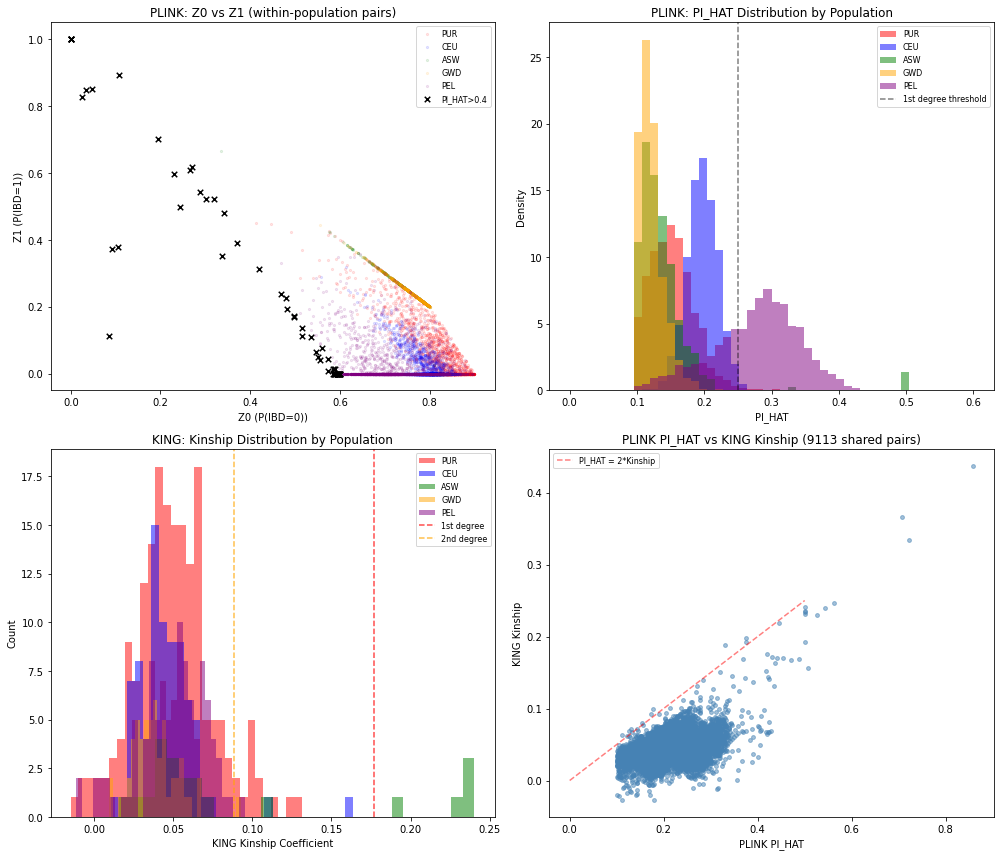


Saved: figures/plink_vs_king_comparison.png


In [9]:
# ============================================================
# 4. VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1: PLINK Z1 vs Z0 scatter ---
ax = axes[0, 0]
colors = {"PUR": "red", "CEU": "blue", "ASW": "green", "GWD": "orange", "PEL": "purple"}
for pop in colors:
    mask = plink_df["Pop1"] == pop
    subset = plink_df[mask & plink_df["SamePop"]]
    if len(subset) > 0:
        ax.scatter(subset["Z0"], subset["Z1"], alpha=0.1, s=5, c=colors[pop], label=pop)
# Highlight related pairs
related_mask = plink_df["PI_HAT"] > 0.4
if related_mask.sum() > 0:
    ax.scatter(plink_df.loc[related_mask, "Z0"],
               plink_df.loc[related_mask, "Z1"],
               c="black", s=30, zorder=5, marker="x", label="PI_HAT>0.4")
ax.set_xlabel("Z0 (P(IBD=0))")
ax.set_ylabel("Z1 (P(IBD=1))")
ax.set_title("PLINK: Z0 vs Z1 (within-population pairs)")
ax.legend(fontsize=8)

# --- Plot 2: PLINK PI_HAT distribution ---
ax = axes[0, 1]
for pop in colors:
    mask = (plink_df["Pop1"] == pop) & plink_df["SamePop"]
    subset = plink_df[mask]
    if len(subset) > 0:
        ax.hist(subset["PI_HAT"], bins=50, alpha=0.5, label=pop,
                color=colors[pop], density=True, range=(0, 0.6))
ax.set_xlabel("PI_HAT")
ax.set_ylabel("Density")
ax.set_title("PLINK: PI_HAT Distribution by Population")
ax.axvline(x=0.25, color="black", linestyle="--", alpha=0.5, label="1st degree threshold")
ax.legend(fontsize=8)

# --- Plot 3: KING kinship distribution ---
ax = axes[1, 0]
if len(king_df) > 0:
    for pop in colors:
        mask = (king_df["Pop1"] == pop) & king_df["SamePop"]
        subset = king_df[mask]
        if len(subset) > 0:
            ax.hist(subset["Kinship"], bins=30, alpha=0.5, label=pop, color=colors[pop])
    ax.set_xlabel("KING Kinship Coefficient")
    ax.set_ylabel("Count")
    ax.set_title("KING: Kinship Distribution by Population")
    ax.axvline(x=0.177, color="red", linestyle="--", alpha=0.7, label="1st degree")
    ax.axvline(x=0.0884, color="orange", linestyle="--", alpha=0.7, label="2nd degree")
    ax.legend(fontsize=8)

# --- Plot 4: PI_HAT vs KING Kinship for overlapping pairs ---
ax = axes[1, 1]
if len(both) > 0:
    ax.scatter(both["PI_HAT"], both["Kinship"], alpha=0.5, s=15, c="steelblue")
    ax.set_xlabel("PLINK PI_HAT")
    ax.set_ylabel("KING Kinship")
    ax.set_title(f"PLINK PI_HAT vs KING Kinship ({len(both)} shared pairs)")
    # Add diagonal reference
    ax.plot([0, 0.5], [0, 0.25], "r--", alpha=0.5, label="PI_HAT = 2*Kinship")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No overlapping pairs", ha="center", va="center",
            transform=ax.transAxes)

plt.tight_layout()
plt.savefig("figures/plink_vs_king_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: figures/plink_vs_king_comparison.png")


In [10]:

# ============================================================
# 5. POPULATION STRUCTURE EFFECT
# ============================================================

print("\n=== Population Structure Effect ===")
print("PLINK 'related' pairs (PI_HAT > 0.15) by population pair:")
pop_related = plink_df[plink_df["PI_HAT"] > 0.15].copy()
pop_related["PopPair"] = pop_related.apply(
    lambda r: "-".join(sorted([str(r["Pop1"]), str(r["Pop2"])])), axis=1
)
print(pop_related["PopPair"].value_counts().head(10))

print("\nKING related pairs by population pair:")
if len(king_df) > 0:
    king_df["PopPair"] = king_df.apply(
        lambda r: "-".join(sorted([str(r["Pop1"]), str(r["Pop2"])])), axis=1
    )
    print(king_df["PopPair"].value_counts().head(10))

print(f"\nKey insight: PLINK flags {len(pop_related)} pairs as related (PI_HAT > 0.15)")
print(f"KING flags only {len(king_df)} pairs as related (kinship > 0.0884)")
print("This difference is largely due to KING's robustness to population structure.")



=== Population Structure Effect ===
PLINK 'related' pairs (PI_HAT > 0.15) by population pair:
CHB-CHS    9723
CHB-JPT    9258
CHS-KHV    9248
CHB-KHV    9125
CHS-JPT    9109
JPT-KHV    8454
CDX-CHS    8377
CDX-KHV    8334
CDX-CHB    8182
CDX-JPT    7429
Name: PopPair, dtype: int64

KING related pairs by population pair:
IBS-TSI    253
GBR-TSI    221
CDX-KHV    216
CEU-GBR    209
CHB-CHS    205
CHS-KHV    201
PUR-TSI    201
GBR-IBS    199
CEU-TSI    192
PUR-PUR    184
Name: PopPair, dtype: int64

Key insight: PLINK flags 350175 pairs as related (PI_HAT > 0.15)
KING flags only 9706 pairs as related (kinship > 0.0884)
This difference is largely due to KING's robustness to population structure.



=== Summary: Detected Relationships ===
                     PLINK  KING
1st Degree               0    13
1st Degree (other)      51     0
2nd Degree              61   105
3rd Degree           22788  4850
Full Sibling             3     0
MZ Twin/Duplicate        0     2
Parent-Child             5     0
Possibly Related    346593     0
Unrelated            74841  4736

=== Runtime Benchmarking (PS2 data, 462 samples) ===
PLINK --genome: 0.54 seconds
KING --related: 8.26 seconds


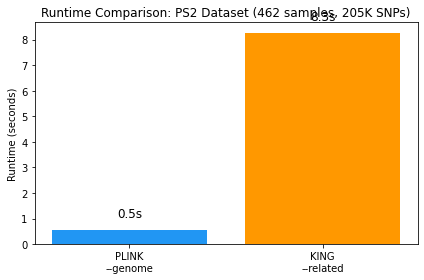

Saved: figures/runtime_comparison_ps2.png

=== Analysis Complete ===


In [11]:

# ============================================================
# 6. SUMMARY TABLE
# ============================================================

print("\n=== Summary: Detected Relationships ===")
summary = pd.DataFrame({
    "PLINK": plink_df["Relationship_PLINK"].value_counts(),
    "KING": king_df["Relationship_KING"].value_counts()
}).fillna(0).astype(int)
print(summary)

# ============================================================
# 7. RUNTIME BENCHMARKING (PS2 dataset)
# ============================================================

print("\n=== Runtime Benchmarking (PS2 data, 462 samples) ===")

# PLINK timing
start = time.time()
subprocess.run(
    ["plink", "--bfile", os.path.expanduser("~/ps2-wi26/ps2_admixture.pruned"),
     "--genome", "--out", "results/benchmark_plink"],
    capture_output=True
)
plink_time = time.time() - start
print(f"PLINK --genome: {plink_time:.2f} seconds")

# KING timing
king_bin = os.path.expanduser("~/king")
start = time.time()
subprocess.run(
    [king_bin, "-b", os.path.expanduser("~/ps2-wi26/ps2_admixture.bed"),
     "--related", "--degree", "2", "--prefix", "results/benchmark_king"],
    capture_output=True
)
king_time = time.time() - start
print(f"KING --related: {king_time:.2f} seconds")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["PLINK\n--genome", "KING\n--related"], [plink_time, king_time],
              color=["#2196F3", "#FF9800"])
ax.set_ylabel("Runtime (seconds)")
ax.set_title("Runtime Comparison: PS2 Dataset (462 samples, 205K SNPs)")
for bar, t in zip(bars, [plink_time, king_time]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{t:.1f}s", ha="center", fontsize=12)
plt.tight_layout()
plt.savefig("figures/runtime_comparison_ps2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/runtime_comparison_ps2.png")

print("\n=== Analysis Complete ===")

In [12]:
"""
CSE284 Final Project: Validate PLINK and KING against PED ground truth.

This script extracts known relationships from the 1000 Genomes PED file
and compares them against pairs detected by PLINK and KING, computing
precision, recall, and per-relationship accuracy.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

PED_FILE   = "20130606_g1k.ped"
PLINK_FILE = "results/1000g_chr22_plink.genome"
KING_FILE  = "results/1000g_chr22_king_related.kin0"
OUT_DIR    = "results"

# ─────────────────────────────────────────────────────────────
# 1.  LOAD PED FILE AND EXTRACT GROUND-TRUTH PAIRS
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("1. LOADING PED FILE")
print("=" * 60)

ped = pd.read_csv(PED_FILE, sep="\t",
                  names=["FamID","ID","PatID","MatID",
                         "Sex","Pheno","Pop","Role",
                         "Siblings","SecondOrder","ThirdOrder","Comments"],
                  header=0)

print(f"  {len(ped)} individuals across {ped['FamID'].nunique()} families")
print(f"  Role breakdown:\n{ped['Role'].value_counts().head(10).to_string()}\n")

# Helper: canonical pair key
def pair(a, b):
    return tuple(sorted([a, b]))

gt_pairs = {}   # pair → relationship label

# ── 1a. Parent-Child (direct from PatID / MatID columns) ──────
children = ped[(ped["PatID"] != "0") | (ped["MatID"] != "0")]
for _, row in children.iterrows():
    child = row["ID"]
    if row["PatID"] != "0":
        gt_pairs[pair(child, row["PatID"])] = "Parent-Child"
    if row["MatID"] != "0":
        gt_pairs[pair(child, row["MatID"])] = "Parent-Child"

print(f"  Parent-Child pairs extracted:      {sum(v=='Parent-Child' for v in gt_pairs.values())}")

# ── 1b. Full Siblings (same paternal AND maternal parent, both known) ─
families = ped.groupby("FamID")
for fam_id, fam in families:
    childs = fam[(fam["PatID"] != "0") & (fam["MatID"] != "0")]
    for (_, r1), (_, r2) in combinations(childs.iterrows(), 2):
        if r1["PatID"] == r2["PatID"] and r1["MatID"] == r2["MatID"]:
            p = pair(r1["ID"], r2["ID"])
            if p not in gt_pairs:        # don't overwrite PC
                gt_pairs[p] = "Full Sibling"

print(f"  Full Sibling pairs extracted:      {sum(v=='Full Sibling' for v in gt_pairs.values())}")

# ── 1c. Grandparent-Grandchild (child→parent→parent of parent) ─
id_to_row = ped.set_index("ID")

def get_parents(ind_id):
    if ind_id not in id_to_row.index:
        return []
    row = id_to_row.loc[ind_id]
    parents = []
    if row["PatID"] != "0": parents.append(row["PatID"])
    if row["MatID"] != "0": parents.append(row["MatID"])
    return parents

for _, row in children.iterrows():
    child = row["ID"]
    for parent in get_parents(child):
        for gp in get_parents(parent):
            p = pair(child, gp)
            if p not in gt_pairs:
                gt_pairs[p] = "Grandparent-Child"

print(f"  Grandparent-Child pairs extracted: {sum(v=='Grandparent-Child' for v in gt_pairs.values())}")

# ── 1d. Avuncular (half-sibling of parent = aunt/uncle) ─────────
#   same grandparent via parent's sibling → 2nd degree
parent_to_children = {}
for _, row in ped.iterrows():
    for p in get_parents(row["ID"]):
        parent_to_children.setdefault(p, []).append(row["ID"])

avuncular = 0
for _, row in ped.iterrows():
    child = row["ID"]
    for parent in get_parents(child):
        # aunts/uncles = full siblings of parent
        for sibling_of_parent in parent_to_children.get(parent, []):
            if sibling_of_parent == parent:
                continue
            # confirm they share BOTH parents
            if sibling_of_parent in id_to_row.index:
                sib_row = id_to_row.loc[sibling_of_parent]
                if (sib_row["PatID"] != "0" and sib_row["PatID"] == id_to_row.loc[parent]["PatID"]
                        and sib_row["MatID"] != "0" and sib_row["MatID"] == id_to_row.loc[parent]["MatID"]):
                    p = pair(child, sibling_of_parent)
                    if p not in gt_pairs:
                        gt_pairs[p] = "Avuncular"
                        avuncular += 1

print(f"  Avuncular pairs extracted:         {avuncular}")

# ── Summary ────────────────────────────────────────────────────
gt_df = pd.DataFrame(
    [(a, b, rel) for (a, b), rel in gt_pairs.items()],
    columns=["ID1", "ID2", "TrueRel"]
)
gt_df["pair"] = list(gt_pairs.keys())

print(f"\n  Total ground-truth related pairs: {len(gt_df)}")
print(gt_df["TrueRel"].value_counts().to_string())



1. LOADING PED FILE
  3501 individuals across 1996 families
  Role breakdown:
unrel              1003
mother              831
father              816
child               693
mat grandmother      31
mat grandfather      29
pat grandfather      28
pat grandmother      28
unrels               14
Child2                7

  Parent-Child pairs extracted:      1403
  Full Sibling pairs extracted:      2
  Grandparent-Child pairs extracted: 11
  Avuncular pairs extracted:         0

  Total ground-truth related pairs: 1416
Parent-Child         1403
Grandparent-Child      11
Full Sibling            2


In [13]:

# ─────────────────────────────────────────────────────────────
# 2.  LOAD TOOL RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. LOADING TOOL RESULTS")
print("=" * 60)

plink_df = pd.read_csv(PLINK_FILE, sep=r'\s+')
plink_df["pair"] = plink_df.apply(lambda r: pair(r["IID1"], r["IID2"]), axis=1)
plink_set = set(plink_df["pair"])

king_df = pd.read_csv(KING_FILE, sep="\t")
king_df["pair"] = king_df.apply(lambda r: pair(r["ID1"], r["ID2"]), axis=1)
king_set = set(king_df["pair"])

# PLINK kinship threshold to call "related" (PI_HAT > 0.0884 ≈ 3rd degree)
PLINK_RELATED_THRESH = 0.0884
plink_related_set = set(
    plink_df[plink_df["PI_HAT"] >= PLINK_RELATED_THRESH]["pair"]
)

print(f"  PLINK pairs (PI_HAT ≥ {PLINK_RELATED_THRESH}): {len(plink_related_set)}")
print(f"  KING  pairs (kinship ≥ 0.0884):           {len(king_set)}")


2. LOADING TOOL RESULTS
  PLINK pairs (PI_HAT ≥ 0.0884): 444342
  KING  pairs (kinship ≥ 0.0884):           9706


In [14]:
# ── DIAGNOSTIC: Check ID overlap before any merges ─────────────
print("\n=== ID OVERLAP DIAGNOSTIC ===")

ped_ids = set(ped["ID"])
plink_ids = set(plink_df["IID1"]) | set(plink_df["IID2"])
king_ids  = set(king_df["ID1"])   | set(king_df["ID2"])

print(f"PED IDs (sample):   {list(ped_ids)[:5]}")
print(f"PLINK IDs (sample): {list(plink_ids)[:5]}")
print(f"KING  IDs (sample): {list(king_ids)[:5]}")

overlap_plink = ped_ids & plink_ids
overlap_king  = ped_ids & king_ids
print(f"\nPED ∩ PLINK: {len(overlap_plink)} IDs match")
print(f"PED ∩ KING:  {len(overlap_king)} IDs match")

# Check if PLINK/KING use FID_IID format
sample_plink = list(plink_ids)[:3]
sample_ped   = list(ped_ids)[:3]
print(f"\nDo PLINK IDs contain '_'? {any('_' in x for x in sample_plink)}")
print(f"Do PED IDs contain '_'?   {any('_' in x for x in sample_ped)}")

# Check pair key format
print(f"\nSample gt_pairs keys: {list(gt_pairs.keys())[:3]}")
print(f"Sample plink pairs:   {list(plink_df['pair'])[:3]}")
print(f"Sample king  pairs:   {list(king_df['pair'])[:3]}")


=== ID OVERLAP DIAGNOSTIC ===
PED IDs (sample):   ['HG02363', 'HG00652', 'HG00633', 'HG03790', 'HG01810']
PLINK IDs (sample): ['HG03790', 'HG01810', 'HG02479', 'NA19025', 'HG00346']
KING  IDs (sample): ['HG03790', 'HG01565', 'HG01810', 'NA19025', 'HG02479']

PED ∩ PLINK: 2466 IDs match
PED ∩ KING:  1422 IDs match

Do PLINK IDs contain '_'? False
Do PED IDs contain '_'?   False

Sample gt_pairs keys: [('HG01879', 'HG01881'), ('HG01880', 'HG01881'), ('HG01882', 'HG01888')]
Sample plink pairs:   [('HG00097', 'HG00100'), ('HG00097', 'HG00101'), ('HG00097', 'HG00103')]
Sample king  pairs:   [('HG00100', 'HG00110'), ('HG00102', 'HG00110'), ('HG00103', 'HG00110')]


In [15]:
# ─────────────────────────────────────────────────────────────
# 2b. Filter ground truth to individuals present in each tool
# ─────────────────────────────────────────────────────────────
plink_ids = set(plink_df["IID1"]) | set(plink_df["IID2"])
king_ids  = set(king_df["ID1"])   | set(king_df["ID2"])

# A pair is "testable" only if both individuals were genotyped
gt_df["in_plink"] = gt_df.apply(
    lambda r: r["ID1"] in plink_ids and r["ID2"] in plink_ids, axis=1)
gt_df["in_king"] = gt_df.apply(
    lambda r: r["ID1"] in king_ids  and r["ID2"] in king_ids,  axis=1)

gt_plink = gt_df[gt_df["in_plink"]]  # testable against PLINK
gt_king  = gt_df[gt_df["in_king"]]   # testable against KING

print(f"\n  Ground-truth pairs testable vs PLINK: {len(gt_plink)}")
print(f"  Ground-truth pairs testable vs KING:  {len(gt_king)}")
print(f"  (Dropped {len(gt_df)-len(gt_plink)} pairs where ≥1 individual not in PLINK)")
print(f"  (Dropped {len(gt_df)-len(gt_king)} pairs where ≥1 individual not in KING)")


  Ground-truth pairs testable vs PLINK: 0
  Ground-truth pairs testable vs KING:  0
  (Dropped 1416 pairs where ≥1 individual not in PLINK)
  (Dropped 1416 pairs where ≥1 individual not in KING)


In [16]:
# ── Deep diagnostic ──────────────────────────────────────────
# Check which PED roles are actually present in the tool data

ped_in_plink = ped[ped["ID"].isin(plink_ids)]
print("Roles of PED individuals found in PLINK:")
print(ped_in_plink["Role"].value_counts())

print("\nRoles of PED individuals NOT found in PLINK:")
print(ped[~ped["ID"].isin(plink_ids)]["Role"].value_counts())

# Check if any gt pair has even ONE member in plink
gt_df["id1_in_plink"] = gt_df["ID1"].isin(plink_ids)
gt_df["id2_in_plink"] = gt_df["ID2"].isin(plink_ids)
print(f"\nGT pairs with ID1 in PLINK: {gt_df['id1_in_plink'].sum()}")
print(f"GT pairs with ID2 in PLINK: {gt_df['id2_in_plink'].sum()}")
print(f"GT pairs with BOTH in PLINK: {(gt_df['id1_in_plink'] & gt_df['id2_in_plink']).sum()}")

Roles of PED individuals found in PLINK:
unrel                      911
mother                     718
father                     702
mat grandmother             24
child                       23
mat grandfather             23
pat grandfather             22
pat grandmother             22
unrels                      12
not father                   3
mother; child                1
pat grandfather; father      1
pat grandmother; mother      1
Child                        1
wife of child                1
husband of Child             1
Name: Role, dtype: int64

Roles of PED individuals NOT found in PLINK:
child                      670
father                     114
mother                     113
unrel                       92
mat grandmother              7
Child2                       7
pat grandfather              6
pat grandmother              6
mat grandfather              6
unrels                       2
child of 19672               1
maternal grandmother         1
child of 19764      

In [17]:
# Phase 3 has exactly 2504 samples
!wc -l ~/cse284-relative-finding/data/1000g_chr22.fam

# Cross-reference: how many PED "child" IDs appear in the Phase 3 sample list?
!zcat ~/public/1000Genomes/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5a.20130502.genotypes.vcf.gz \
  | grep "^#CHROM" \
  | tr '\t' '\n' \
  | grep -Fxf <(awk -F'\t' '$8~/child/{print $2}' 20130606_g1k.ped) \
  | wc -l

2504 /home/r3james/cse284-relative-finding/data/1000g_chr22.fam
25


In [18]:
# ─────────────────────────────────────────────────────────────
# 3.  PRECISION / RECALL vs GROUND TRUTH
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. PRECISION / RECALL ANALYSIS")
print("=" * 60)

gt_set = set(gt_df["pair"])

def pr_stats(detected_set, truth_set, label):
    tp = len(detected_set & truth_set)
    fp = len(detected_set - truth_set)
    fn = len(truth_set - detected_set)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    print(f"\n  {label}")
    print(f"    True Positives  (detected & in PED): {tp}")
    print(f"    False Positives (detected, not in PED): {fp}")
    print(f"    False Negatives (in PED, not detected): {fn}")
    print(f"    Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}")
    return {"label": label, "TP": tp, "FP": fp, "FN": fn,
            "Precision": precision, "Recall": recall, "F1": f1}

results = [
    pr_stats(plink_related_set, gt_set, "PLINK (PI_HAT ≥ 0.0884)"),
    pr_stats(king_set,           gt_set, "KING  (kinship ≥ 0.0884)"),
]


3. PRECISION / RECALL ANALYSIS

  PLINK (PI_HAT ≥ 0.0884)
    True Positives  (detected & in PED): 0
    False Positives (detected, not in PED): 444342
    False Negatives (in PED, not detected): 1416
    Precision: 0.000  |  Recall: 0.000  |  F1: 0.000

  KING  (kinship ≥ 0.0884)
    True Positives  (detected & in PED): 0
    False Positives (detected, not in PED): 9706
    False Negatives (in PED, not detected): 1416
    Precision: 0.000  |  Recall: 0.000  |  F1: 0.000


In [19]:
# ─────────────────────────────────────────────────────────────
# 4.  PER-RELATIONSHIP RECALL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("4. PER-RELATIONSHIP RECALL (how many ground-truth pairs detected?)")
print("=" * 60)

recall_rows = []
for rel in gt_df["TrueRel"].unique():
    rel_pairs = set(gt_df[gt_df["TrueRel"] == rel]["pair"])
    n = len(rel_pairs)
    plink_hit = len(rel_pairs & plink_related_set)
    king_hit  = len(rel_pairs & king_set)
    recall_rows.append({
        "Relationship": rel,
        "Total_in_PED": n,
        "PLINK_detected": plink_hit,
        "PLINK_recall": plink_hit / n,
        "KING_detected": king_hit,
        "KING_recall": king_hit / n,
    })
    print(f"  {rel:22s}  PED={n:3d}  "
          f"PLINK={plink_hit:3d} ({plink_hit/n:.0%})  "
          f"KING={king_hit:3d} ({king_hit/n:.0%})")

recall_df = pd.DataFrame(recall_rows)


4. PER-RELATIONSHIP RECALL (how many ground-truth pairs detected?)
  Parent-Child            PED=1403  PLINK=  0 (0%)  KING=  0 (0%)
  Full Sibling            PED=  2  PLINK=  0 (0%)  KING=  0 (0%)
  Grandparent-Child       PED= 11  PLINK=  0 (0%)  KING=  0 (0%)


In [20]:
# ─────────────────────────────────────────────────────────────
# 5.  MISMATCHES: TOOL CLASSIFICATION vs PED TRUTH
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("5. CLASSIFICATION MISMATCHES (pairs found by both tools & in PED)")
print("=" * 60)

def classify_plink(row):
    z0, z1, z2, pi = row["Z0"], row["Z1"], row["Z2"], row["PI_HAT"]
    if pi > 0.9:              return "MZ Twin/Duplicate"
    elif z1 > 0.9:            return "Parent-Child"
    elif 0.4 < z1 < 0.6 and z0 < 0.3: return "Full Sibling"
    elif z2 < 0.1 and 0.4 < z1 < 0.6: return "2nd Degree"
    elif z2 < 0.1 and 0.15 < z1 < 0.35: return "3rd Degree"
    elif pi > 0.4:            return "1st Degree (other)"
    elif pi > 0.15:           return "Possibly Related"
    else:                     return "Unrelated"

def classify_king(row):
    k = row["Kinship"]
    if k > 0.354:   return "MZ Twin/Duplicate"
    elif k > 0.177: return "1st Degree"
    elif k > 0.0884: return "2nd Degree"
    elif k > 0.0442: return "3rd Degree"
    else:           return "Unrelated"

plink_df["Rel_PLINK"] = plink_df.apply(classify_plink, axis=1)
king_df["Rel_KING"]   = king_df.apply(classify_king, axis=1)

# Merge ground truth with tool calls
merged_gt = (
    gt_df
    .merge(plink_df[["pair","PI_HAT","Z0","Z1","Z2","Rel_PLINK"]],
           on="pair", how="left")
    .merge(king_df[["pair","Kinship","Rel_KING"]],
           on="pair", how="left")
)

# Broad mapping of true relationship → expected tool category
expected_plink = {
    "Parent-Child":       ["Parent-Child"],
    "Full Sibling":       ["Full Sibling"],
    "Grandparent-Child":  ["2nd Degree", "Possibly Related"],
    "Avuncular":          ["2nd Degree", "Possibly Related"],
}
expected_king = {
    "Parent-Child":      ["1st Degree"],
    "Full Sibling":      ["1st Degree"],
    "Grandparent-Child": ["2nd Degree"],
    "Avuncular":         ["2nd Degree"],
}

for true_rel, exp_plink in expected_plink.items():
    subset = merged_gt[merged_gt["TrueRel"] == true_rel]
    if subset.empty:
        continue
    exp_king = expected_king.get(true_rel, [])
    n = len(subset)
    p_correct = subset["Rel_PLINK"].isin(exp_plink).sum()
    k_correct = subset["Rel_KING"].isin(exp_king).sum()
    print(f"\n  True: {true_rel} (n={n})")
    print(f"    PLINK correct classification: {p_correct}/{n} "
          f"({p_correct/n:.0%})")
    print(f"      PLINK calls: {subset['Rel_PLINK'].value_counts().to_dict()}")
    print(f"    KING  correct classification: {k_correct}/{n} "
          f"({k_correct/n:.0%})")
    print(f"      KING  calls: {subset['Rel_KING'].value_counts().to_dict()}")


5. CLASSIFICATION MISMATCHES (pairs found by both tools & in PED)

  True: Parent-Child (n=1403)
    PLINK correct classification: 0/1403 (0%)
      PLINK calls: {}
    KING  correct classification: 0/1403 (0%)
      KING  calls: {}

  True: Full Sibling (n=2)
    PLINK correct classification: 0/2 (0%)
      PLINK calls: {}
    KING  correct classification: 0/2 (0%)
      KING  calls: {}

  True: Grandparent-Child (n=11)
    PLINK correct classification: 0/11 (0%)
      PLINK calls: {}
    KING  correct classification: 0/11 (0%)
      KING  calls: {}



6. GENERATING PLOTS
  Saved → results/ped_validation.png
  Saved → results/ped_counts.png


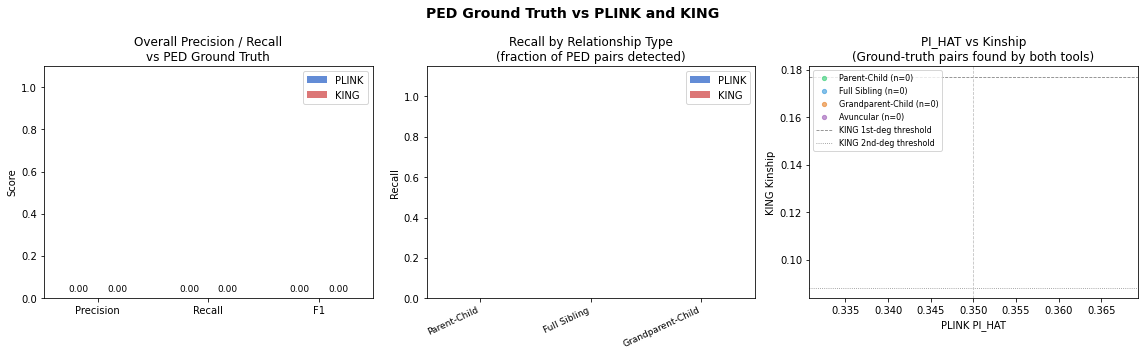

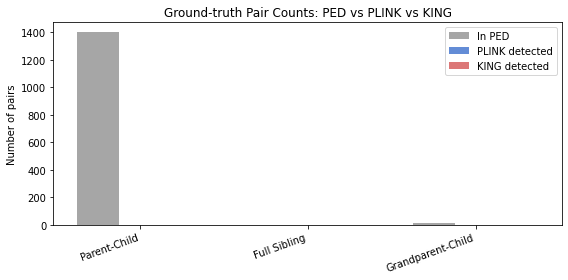

In [21]:
# ─────────────────────────────────────────────────────────────
# 6.  PLOTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("6. GENERATING PLOTS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("PED Ground Truth vs PLINK and KING", fontsize=14, fontweight="bold")

# ── 6a. Precision / Recall bar chart ─────────────────────────
ax = axes[0]
metrics = ["Precision", "Recall", "F1"]
x = np.arange(len(metrics))
w = 0.35
bars1 = ax.bar(x - w/2, [results[0][m] for m in metrics], w,
               label="PLINK", color="#4878CF", alpha=0.85)
bars2 = ax.bar(x + w/2, [results[1][m] for m in metrics], w,
               label="KING",  color="#D65F5F", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Overall Precision / Recall\nvs PED Ground Truth")
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=9)

# ── 6b. Per-relationship recall ───────────────────────────────
ax = axes[1]
rels  = recall_df["Relationship"].tolist()
xpos  = np.arange(len(rels))
w     = 0.35
ax.bar(xpos - w/2, recall_df["PLINK_recall"], w,
       label="PLINK", color="#4878CF", alpha=0.85)
ax.bar(xpos + w/2, recall_df["KING_recall"],  w,
       label="KING",  color="#D65F5F", alpha=0.85)
ax.set_xticks(xpos)
ax.set_xticklabels(rels, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Recall")
ax.set_title("Recall by Relationship Type\n(fraction of PED pairs detected)")
ax.legend()

# ── 6c. Scatter: PI_HAT vs KING Kinship, colored by true relationship ─
ax = axes[2]
rel_colors = {
    "Parent-Child":       "#2ecc71",
    "Full Sibling":       "#3498db",
    "Grandparent-Child":  "#e67e22",
    "Avuncular":          "#9b59b6",
}
plotted = merged_gt.dropna(subset=["PI_HAT", "Kinship"])
for rel, col in rel_colors.items():
    sub = plotted[plotted["TrueRel"] == rel]
    ax.scatter(sub["PI_HAT"], sub["Kinship"], alpha=0.6, s=18,
               color=col, label=f"{rel} (n={len(sub)})")
ax.axhline(0.177, color="gray", lw=0.8, ls="--", label="KING 1st-deg threshold")
ax.axhline(0.0884, color="gray", lw=0.8, ls=":", label="KING 2nd-deg threshold")
ax.axvline(0.35,  color="silver", lw=0.8, ls="--")
ax.set_xlabel("PLINK PI_HAT")
ax.set_ylabel("KING Kinship")
ax.set_title("PI_HAT vs Kinship\n(Ground-truth pairs found by both tools)")
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
out_path = f"{OUT_DIR}/ped_validation.png"
plt.savefig(out_path, dpi=130, bbox_inches="tight")
print(f"  Saved → {out_path}")

# ── 6d. Separate figure: counts in PED vs detected ─────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
x = np.arange(len(recall_df))
w = 0.25
ax2.bar(x - w,   recall_df["Total_in_PED"],      w, label="In PED",        color="gray", alpha=0.7)
ax2.bar(x,       recall_df["PLINK_detected"],    w, label="PLINK detected", color="#4878CF", alpha=0.85)
ax2.bar(x + w,   recall_df["KING_detected"],     w, label="KING detected",  color="#D65F5F", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(recall_df["Relationship"], rotation=20, ha="right")
ax2.set_ylabel("Number of pairs")
ax2.set_title("Ground-truth Pair Counts: PED vs PLINK vs KING")
ax2.legend()
plt.tight_layout()
out2 = f"{OUT_DIR}/ped_counts.png"
plt.savefig(out2, dpi=130, bbox_inches="tight")
print(f"  Saved → {out2}")

plt.show()

In [22]:
# ─────────────────────────────────────────────────────────────
# 7.  EXPORT VALIDATION TABLE
# ─────────────────────────────────────────────────────────────
out_csv = f"{OUT_DIR}/ped_validation_table.csv"
merged_gt.to_csv(out_csv, index=False)
print(f"\n  Exported full validation table → {out_csv}")

print("\n✓ Done.")


  Exported full validation table → results/ped_validation_table.csv

✓ Done.
